# 💰 Personal Finance Classifier — CerminSaku AI
**Dataset:** 11.500 transaksi (2020–2024)  
**Goal:** Klasifikasi `Category` transaksi dari fitur Amount, Type, dan waktu  
**Model:** Random Forest dengan tuning anti-overfitting


## 1. Install & Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight
import joblib

print('✅ Import berhasil')

✅ Import berhasil


## 2. Load Dataset

In [2]:
from google.colab import files
uploaded = files.upload()  # Upload file Personal_Finance_Dataset_11500.csv

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f'Shape: {df.shape}')
print(f'Kolom: {df.columns.tolist()}')
df.head()

Saving Personal_Finance_Dataset_11500.csv to Personal_Finance_Dataset_11500.csv
Shape: (11500, 5)
Kolom: ['Date', 'Transaction Description', 'Category', 'Amount', 'Type']


,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense


## 3. Exploratory Data Analysis (EDA)

In [3]:
print('=== Info Dataset ===')
print(df.info())
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Distribusi Category ===')
print(df['Category'].value_counts())
print('\n=== Distribusi Type ===')
print(df['Type'].value_counts())

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     11500 non-null  object 
 1   Transaction Description  11500 non-null  object 
 2   Category                 11500 non-null  object 
 3   Amount                   11500 non-null  float64
 4   Type                     11500 non-null  object 
dtypes: float64(1), object(4)
memory usage: 449.3+ KB
None

=== Missing Values ===
Date                       0
Transaction Description    0
Category                   0
Amount                     0
Type                       0
dtype: int64

=== Distribusi Category ===
Category
Utilities           2071
Shopping            1982
Food & Drink        1976
Entertainment       1972
Transport           1799
Income               521
Salary               424
Rent                 165
Travel        

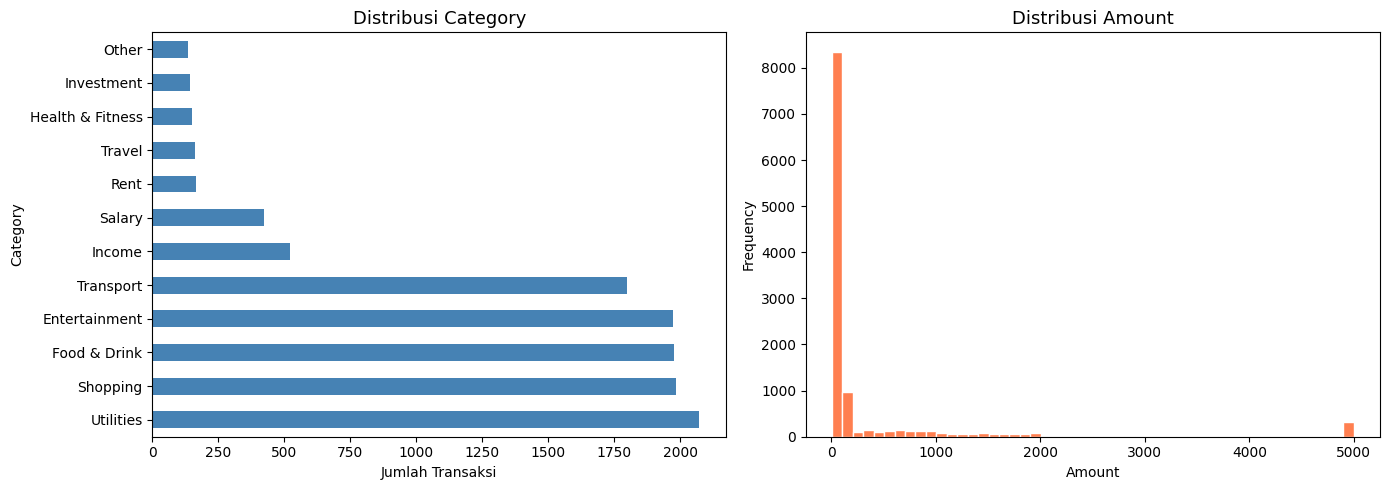

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


df['Category'].value_counts().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Distribusi Category', fontsize=13)
axes[0].set_xlabel('Jumlah Transaksi')


df['Amount'].plot(kind='hist', bins=50, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Distribusi Amount', fontsize=13)
axes[1].set_xlabel('Amount')

plt.tight_layout()
plt.show()

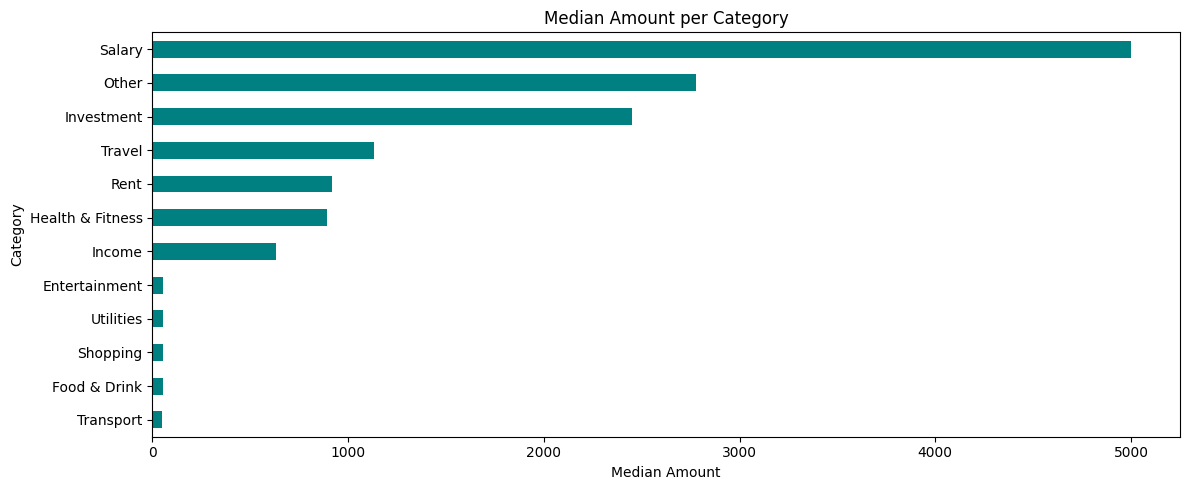

In [5]:
plt.figure(figsize=(12, 5))
df.groupby('Category')['Amount'].median().sort_values().plot(kind='barh', color='teal')
plt.title('Median Amount per Category')
plt.xlabel('Median Amount')
plt.tight_layout()
plt.show()

## 4. Preprocessing & Feature Engineering

In [6]:
df_proc = df.copy()


df_proc['Date'] = pd.to_datetime(df_proc['Date'])
df_proc['year']       = df_proc['Date'].dt.year
df_proc['month']      = df_proc['Date'].dt.month
df_proc['day']        = df_proc['Date'].dt.day
df_proc['dayofweek']  = df_proc['Date'].dt.dayofweek
df_proc['quarter']    = df_proc['Date'].dt.quarter
df_proc['is_weekend'] = df_proc['dayofweek'].isin([5, 6]).astype(int)


df_proc['type_encoded'] = (df_proc['Type'] == 'Income').astype(int)


df_proc['log_amount']    = np.log1p(df_proc['Amount'])
df_proc['amount_binned'] = pd.qcut(df_proc['Amount'], q=5,
                                    labels=[0,1,2,3,4]).astype(int)


le_cat = LabelEncoder()
df_proc['label'] = le_cat.fit_transform(df_proc['Category'])

print('Kelas yang ada:')
for i, c in enumerate(le_cat.classes_):
    print(f'  {i}: {c}')

Kelas yang ada:
  0: Entertainment
  1: Food & Drink
  2: Health & Fitness
  3: Income
  4: Investment
  5: Other
  6: Rent
  7: Salary
  8: Shopping
  9: Transport
  10: Travel
  11: Utilities


In [7]:
FEATURES = [
    'Amount', 'log_amount', 'amount_binned',
    'type_encoded',
    'year', 'month', 'day', 'dayofweek',
    'quarter', 'is_weekend'
]

X = df_proc[FEATURES].values
y = df_proc['label'].values

print(f'Shape X: {X.shape}, y: {y.shape}')

Shape X: (11500, 10), y: (11500,)


## 5. Split Data (Train / Val / Test)

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train : {X_train.shape[0]} baris')
print(f'Val   : {X_val.shape[0]} baris')
print(f'Test  : {X_test.shape[0]} baris')


scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

Train : 8050 baris
Val   : 1725 baris
Test  : 1725 baris


## 6. Training Random Forest (Anti-Overfitting)

In [9]:
rf = RandomForestClassifier(
    n_estimators     = 200,
    max_depth        = 15,
    min_samples_leaf = 5,
    min_samples_split= 10,
    max_features     = 'sqrt',
    class_weight     = 'balanced',
    random_state     = 42,
    n_jobs           = -1
)

rf.fit(X_train_sc, y_train)
print('✅ Training selesai')

✅ Training selesai


## 7. Evaluasi Model

In [10]:
acc_train = accuracy_score(y_train, rf.predict(X_train_sc))
acc_val   = accuracy_score(y_val,   rf.predict(X_val_sc))
acc_test  = accuracy_score(y_test,  rf.predict(X_test_sc))

print(f'Akurasi Train : {acc_train:.4f}')
print(f'Akurasi Val   : {acc_val:.4f}')
print(f'Akurasi Test  : {acc_test:.4f}')
print(f'Gap Train-Val : {acc_train - acc_val:.4f}  (< 0.05 = tidak overfit)')

Akurasi Train : 0.7612
Akurasi Val   : 0.2354
Akurasi Test  : 0.2452
Gap Train-Val : 0.5259  (< 0.05 = tidak overfit)


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train_sc, y_train, cv=cv,
                             scoring='f1_macro', n_jobs=-1)

print(f'CV F1-Macro : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Scores tiap fold: {cv_scores.round(4)}')

CV F1-Macro : 0.3262 ± 0.0140
Scores tiap fold: [0.3206 0.3046 0.3226 0.3412 0.3419]


In [12]:
y_pred = rf.predict(X_test_sc)
print(classification_report(y_test, y_pred,
                              target_names=le_cat.classes_))

                  precision    recall  f1-score   support

   Entertainment       0.19      0.18      0.18       296
    Food & Drink       0.22      0.18      0.20       297
Health & Fitness       0.07      0.13      0.09        23
          Income       0.91      0.90      0.90        78
      Investment       0.62      0.62      0.62        21
           Other       0.62      0.50      0.56        20
            Rent       0.05      0.12      0.07        25
          Salary       0.85      0.73      0.79        64
        Shopping       0.17      0.15      0.16       297
       Transport       0.19      0.24      0.21       270
          Travel       0.12      0.29      0.17        24
       Utilities       0.19      0.17      0.18       310

        accuracy                           0.25      1725
       macro avg       0.35      0.35      0.34      1725
    weighted avg       0.26      0.25      0.25      1725



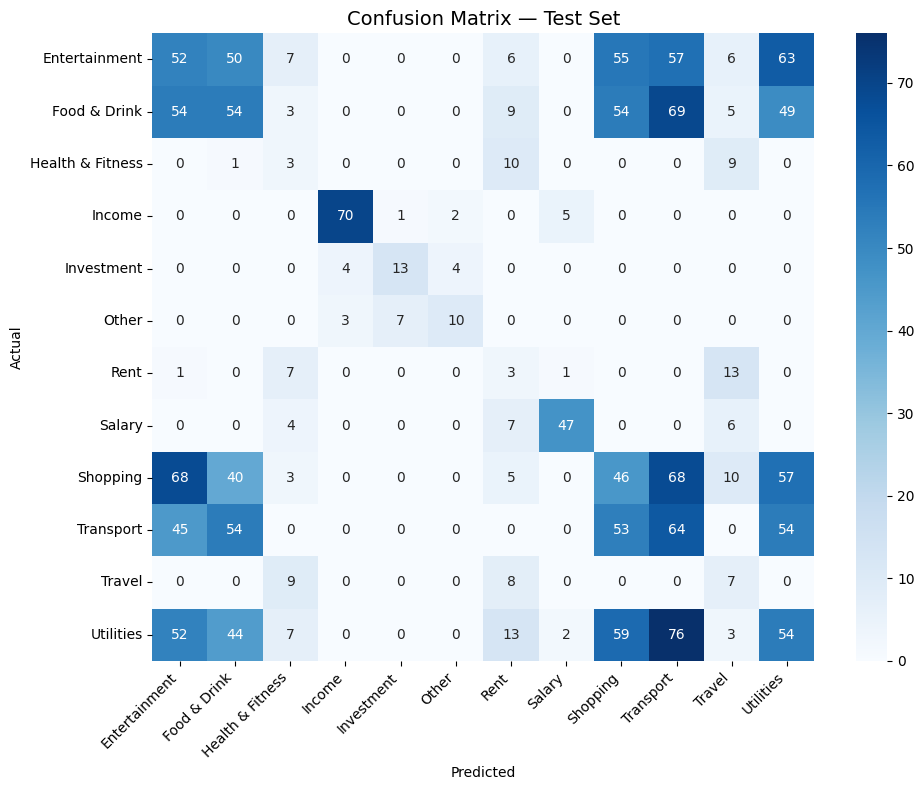

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_cat.classes_,
            yticklabels=le_cat.classes_)
plt.title('Confusion Matrix — Test Set', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

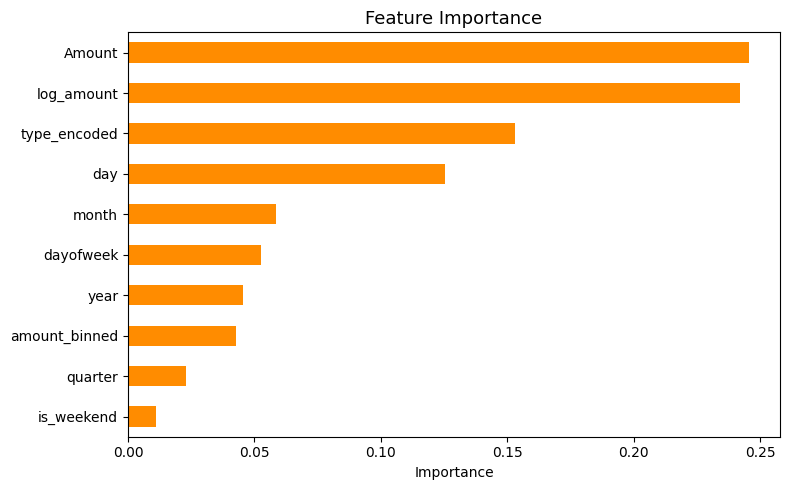

Amount           0.245574
log_amount       0.241967
type_encoded     0.153152
day              0.125492
month            0.058720
dayofweek        0.052579
year             0.045443
amount_binned    0.042800
quarter          0.023103
is_weekend       0.011170
dtype: float64


In [14]:
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
fi.plot(kind='barh', color='darkorange')
plt.title('Feature Importance', fontsize=13)
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print(fi)

## 8. Simpan Model (kompatibel dengan repo GitHub)

In [15]:
joblib.dump(rf,     'best_random_forest_model.pkl')
joblib.dump(scaler, 'scaler.bin')
joblib.dump(le_cat, 'label_encoder.pkl')

print('✅ Model disimpan:')
print('   best_random_forest_model.pkl')
print('   scaler.bin')
print('   label_encoder.pkl')


from google.colab import files
files.download('best_random_forest_model.pkl')
files.download('scaler.bin')
files.download('label_encoder.pkl')

✅ Model disimpan:
   best_random_forest_model.pkl
   scaler.bin
   label_encoder.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Prediksi Transaksi Baru (Inference)

In [16]:
import pandas as pd
import numpy as np


_, amount_bin_edges = pd.qcut(df_proc['Amount'], q=5, labels=False, retbins=True, duplicates='drop')

def predict_category(amount, type_str, date_str):
    """
    Prediksi kategori transaksi baru.

    Args:
        amount   : float — nominal transaksi
        type_str : str   — 'Income' atau 'Expense'
        date_str : str   — format 'YYYY-MM-DD'

    Returns:
        str — prediksi kategori
    """
    date = pd.to_datetime(date_str)


    amount_binned_val = pd.cut(
        [amount],
        bins=amount_bin_edges,
        labels=[0,1,2,3,4],
        include_lowest=True
    ).fillna(4).astype(int)[0]

    features = np.array([[
        amount,
        np.log1p(amount),
        amount_binned_val,
        1 if type_str == 'Income' else 0,
        date.year, date.month, date.day,
        date.dayofweek, date.quarter,
        1 if date.dayofweek in [5, 6] else 0
    ]])
    features_sc = scaler.transform(features)
    pred = rf.predict(features_sc)[0]
    return le_cat.inverse_transform([pred])[0]



contoh = [
    (5000.00, 'Income',  '2024-01-15'),
    (  50.00, 'Expense', '2024-03-20'),
    ( 120.00, 'Expense', '2024-07-05'),
    (1200.00, 'Expense', '2024-12-24'),
]

print(f'{"Amount":>10} | {"Type":>8} | {"Date":>12} | {"Prediksi Category"}')
print('-' * 55)
for amount, tipe, tgl in contoh:
    pred = predict_category(amount, tipe, tgl)
    print(f'{amount:>10.2f} | {tipe:>8} | {tgl:>12} | {pred}')


    Amount |     Type |         Date | Prediksi Category
-------------------------------------------------------
   5000.00 |   Income |   2024-01-15 | Salary
     50.00 |  Expense |   2024-03-20 | Entertainment
    120.00 |  Expense |   2024-07-05 | Rent
   1200.00 |  Expense |   2024-12-24 | Travel


## 10. Ringkasan Hasil

In [17]:
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print('=' * 50)
print('         RINGKASAN HASIL MODEL')
print('=' * 50)
print(f'  Dataset        : 11.500 transaksi (2020-2024)')
print(f'  Fitur          : {len(FEATURES)} fitur')
print(f'  Kelas          : {len(le_cat.classes_)} kategori')
print(f'  Akurasi Train  : {acc_train:.4f}')
print(f'  Akurasi Val    : {acc_val:.4f}')
print(f'  Akurasi Test   : {acc_test:.4f}')
print(f'  F1 Macro Test  : {f1_macro:.4f}')
print(f'  F1 Weighted    : {f1_weighted:.4f}')
print(f'  CV F1 (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'  Gap overfit    : {acc_train - acc_val:.4f}')
print('=' * 50)

         RINGKASAN HASIL MODEL
  Dataset        : 11.500 transaksi (2020-2024)
  Fitur          : 10 fitur
  Kelas          : 12 kategori
  Akurasi Train  : 0.7612
  Akurasi Val    : 0.2354
  Akurasi Test   : 0.2452
  F1 Macro Test  : 0.3449
  F1 Weighted    : 0.2489
  CV F1 (5-fold) : 0.3262 ± 0.0140
  Gap overfit    : 0.5259
